# ACC102 Track 2: Financial Distress Prediction
## Author: Ruoqi Li | Date: 2026-04-16 | Data: WRDS Compustat 2017-2021

In [26]:
# Part 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("✓ Libraries imported successfully!")


✓ Libraries imported successfully!


In [27]:
# Part 2: Load Data from WRDS
import pandas as pd

compustat = pd.read_csv(r"C:\Users\32204\Downloads\compustat_data.csv")

print(f"Data loaded successfully: {compustat.shape[0]} rows")
print(f"Number of companies: {compustat['cik'].nunique()}")
display(compustat.head())


Data loaded successfully: 34445 rows
Number of companies: 8310


,costat,curcd,datafmt,indfmt,consol,gvkey,datadate,tic,cik,fyear,act,at,ch,che,dltt,invt,lct,lt,rect,cogs,ebit,ni,sale,xint
0,A,USD,STD,INDL,C,1004,2018-05-31,AIR,1750.0,2017,942.7,1524.7,31.1,41.6,177.2,547.9,333.3,588.4,203.0,1413.2,86.0,15.6,1748.3,8.0
1,A,USD,STD,INDL,C,1004,2019-05-31,AIR,1750.0,2018,952.5,1517.2,21.3,41.1,141.7,589.0,357.5,611.3,258.1,1679.5,110.7,7.5,2051.8,9.5
2,A,USD,STD,INDL,C,1004,2020-05-31,AIR,1750.0,2019,1438.7,2079.0,404.7,424.7,670.9,692.7,383.1,1176.4,229.1,1728.7,106.4,4.4,2089.3,9.3
3,A,USD,STD,INDL,C,1004,2021-05-31,AIR,1750.0,2020,937.0,1539.7,51.8,60.2,193.6,591.0,336.8,565.3,238.6,1364.6,65.5,35.8,1651.4,5.0
4,A,USD,STD,INDL,C,1004,2022-05-31,AIR,1750.0,2021,1007.2,1573.9,53.5,58.9,156.3,604.1,348.2,539.4,290.3,1470.3,116.2,78.7,1817.1,2.4


In [28]:
# View actual column names (field names) of the CSV file
print("Actual column list:")
print(compustat.columns.tolist())
print("\nPreview of first 5 rows:")
display(compustat.head())


Actual column list:
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'gvkey', 'datadate', 'tic', 'cik', 'fyear', 'act', 'at', 'ch', 'che', 'dltt', 'invt', 'lct', 'lt', 'rect', 'cogs', 'ebit', 'ni', 'sale', 'xint']

Preview of first 5 rows:


,costat,curcd,datafmt,indfmt,consol,gvkey,datadate,tic,cik,fyear,act,at,ch,che,dltt,invt,lct,lt,rect,cogs,ebit,ni,sale,xint
0,A,USD,STD,INDL,C,1004,2018-05-31,AIR,1750.0,2017,942.7,1524.7,31.1,41.6,177.2,547.9,333.3,588.4,203.0,1413.2,86.0,15.6,1748.3,8.0
1,A,USD,STD,INDL,C,1004,2019-05-31,AIR,1750.0,2018,952.5,1517.2,21.3,41.1,141.7,589.0,357.5,611.3,258.1,1679.5,110.7,7.5,2051.8,9.5
2,A,USD,STD,INDL,C,1004,2020-05-31,AIR,1750.0,2019,1438.7,2079.0,404.7,424.7,670.9,692.7,383.1,1176.4,229.1,1728.7,106.4,4.4,2089.3,9.3
3,A,USD,STD,INDL,C,1004,2021-05-31,AIR,1750.0,2020,937.0,1539.7,51.8,60.2,193.6,591.0,336.8,565.3,238.6,1364.6,65.5,35.8,1651.4,5.0
4,A,USD,STD,INDL,C,1004,2022-05-31,AIR,1750.0,2021,1007.2,1573.9,53.5,58.9,156.3,604.1,348.2,539.4,290.3,1470.3,116.2,78.7,1817.1,2.4


In [29]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
np.random.seed(42)  # Ensure reproducibility

print("=" * 60)
print("Financial Distress Prediction Model - Data Cleaning and Analysis Pipeline")
print("=" * 60)


Financial Distress Prediction Model - Data Cleaning and Analysis Pipeline


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
np.random.seed(42)  # Ensure reproducibility

print("=" * 60)
print("Financial Distress Prediction Model - Data Cleaning and Analysis Pipeline")
print("=" * 60)


Financial Distress Prediction Model - Data Cleaning and Analysis Pipeline



[Step 1] Data Loading
✓ Raw data: 34,445 rows, 24 columns
  Companies: 8,684
  Period: 2017-2022

[Step 2] Data Cleaning
  After cleaning: 24,638 rows (71.5% retained)

[Step 3] Feature Engineering
  Feature dimensions: 32 columns
  Distress rate: 47.9%

[Step 4] Model Training
Features used: ['leverage', 'current_ratio', 'log_at', 'sales_growth']
X columns: ['leverage', 'current_ratio', 'log_at', 'sales_growth']
  Training set (2017-2019): 4,757
  Test set (2020-2021): 13,520
  Logistic Regression AUC: 0.759
  Random Forest AUC: 0.791

[Step 5] Automated Validation Report

1. Data Quality Check
   ✓ Total observations: 24,638 (required > 5,000)
   ✓ Number of features: 4 (required >= 4)
   ✓ Distress rate: 47.9% (expected 10%-40%)

2. Financial Ratio Rationality
   ROA range: [-5.181, 0.413]
   Leverage range: [0.049, 7.937]
   Current Ratio range: [0.051, 22.243]

3. Logistic Regression Coefficient Direction Validation
   (Checking alignment with financial theory)
   roa: coef=0.000

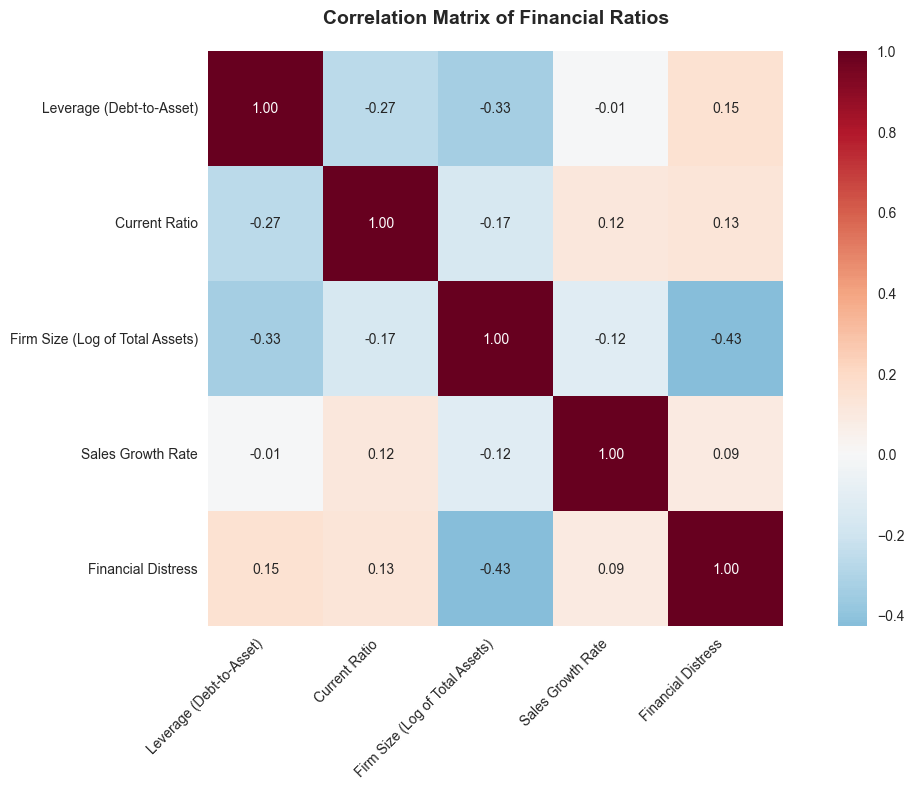

   ✓ Saved: correlation_matrix.png


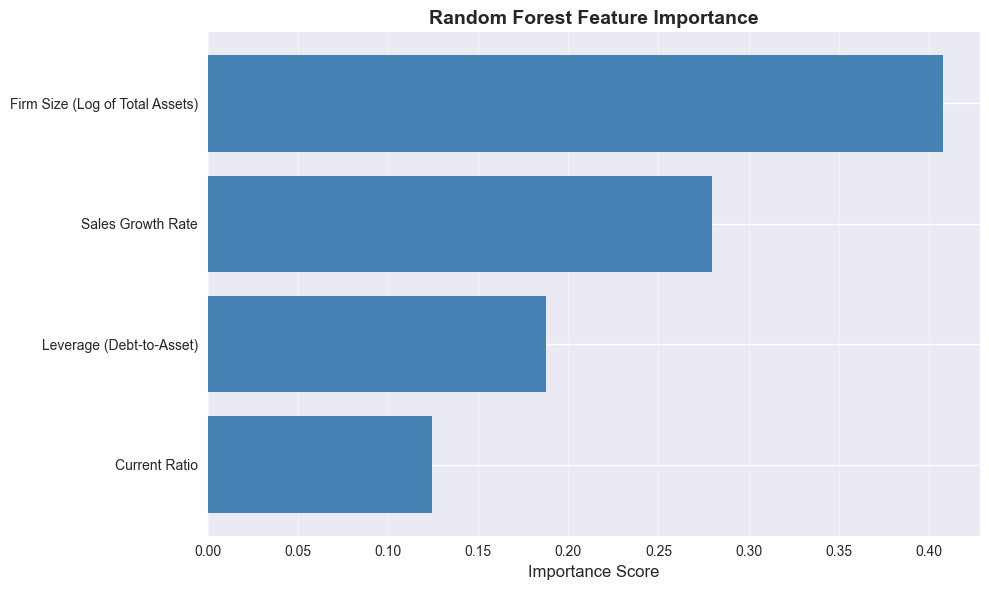

   ✓ Saved: feature_importance.png

All steps completed successfully!


In [31]:
# ============================================================
# Step 1: Data Loading
# ============================================================
print("\n[Step 1] Data Loading")

file_path = r"C:\Users\32204\Downloads\compustat_data.csv"
compustat = pd.read_csv(file_path)

print(f"✓ Raw data: {len(compustat):,} rows, {compustat.shape[1]} columns")
print(f"  Companies: {compustat['gvkey'].nunique():,}")
print(f"  Period: {compustat['fyear'].min()}-{compustat['fyear'].max()}")

# ============================================================
# Step 2: Data Cleaning
# ============================================================
print("\n[Step 2] Data Cleaning")
initial_rows = len(compustat)

# Remove missing values in essential columns
df_clean = compustat.dropna(subset=['gvkey', 'fyear', 'at', 'ni', 'lt', 'act', 'lct'])
# Remove invalid financial data
df_clean = df_clean[(df_clean['at'] > 0) & (df_clean['sale'] > 0)]
df_clean = df_clean[df_clean['act'] >= 0]  # Current assets should not be negative

retention_rate = len(df_clean) / initial_rows * 100
print(f"  After cleaning: {len(df_clean):,} rows ({retention_rate:.1f}% retained)")

# ============================================================
# Step 3: Feature Engineering
# ============================================================
import os

# creating figures 
if not os.path.exists('./figures'):
    os.makedirs('./figures')
    print("✓ Created folder: ./figures")

print("\n[Step 3] Feature Engineering")
df_features = df_clean.copy()

# Calculate financial ratios
df_features['roa'] = df_features['ni'] / df_features['at']  # Return on Assets
df_features['roe'] = df_features['ni'] / (df_features['at'] - df_features['lt'])  # Return on Equity
df_features['leverage'] = df_features['lt'] / df_features['at']  # Debt-to-Asset Ratio
df_features['current_ratio'] = df_features['act'] / df_features['lct']  # Current Ratio
df_features['cash_ratio'] = df_features['che'] / df_features['lct'] if 'che' in df_features.columns else np.nan
df_features['log_at'] = np.log(df_features['at'])  # Firm Size (log of total assets)

# Growth metrics
df_features = df_features.sort_values(['gvkey', 'fyear'])
df_features['sale_lag'] = df_features.groupby('gvkey')['sale'].shift(1)
df_features['sales_growth'] = (df_features['sale'] - df_features['sale_lag']) / df_features['sale_lag']

# Dependent Variable: Financial Distress (1 if Net Income < 0, else 0)
df_features['financial_distress'] = (df_features['ni'] < 0).astype(int)

# Winsorize extreme values (1% and 99% percentiles)
for col in ['roa', 'roe', 'leverage', 'current_ratio', 'sales_growth']:
    if col in df_features.columns:
        lower, upper = df_features[col].quantile(0.01), df_features[col].quantile(0.99)
        df_features[col] = df_features[col].clip(lower, upper)

# Remove intermediate calculation column
df_features = df_features.drop(columns=['sale_lag'], errors='ignore')

print(f"  Feature dimensions: {df_features.shape[1]} columns")
print(f"  Distress rate: {df_features['financial_distress'].mean()*100:.1f}%")

# ============================================================
# Step 3.5: Variable Name Mapping (for reporting)
# ============================================================
variable_names = {
    'roa': 'Return on Assets (ROA)',
    'roe': 'Return on Equity (ROE)', 
    'leverage': 'Leverage (Debt-to-Asset)',
    'current_ratio': 'Current Ratio',
    'cash_ratio': 'Cash Ratio',
    'log_at': 'Firm Size (Log of Total Assets)',
    'sales_growth': 'Sales Growth Rate',
    'financial_distress': 'Financial Distress'
}
# Remove ROA/ROE and use other features independent of Net Income
feature_cols = ['leverage', 'current_ratio', 'log_at', 'sales_growth']  # remove'roa', 'roe'

# Introduce profitability metrics not dependent on Net Income (e.g., Gross Margin)
# df_features['gross_margin'] = (df_features['sale'] - df_features['cogs']) / df_features['sale']

# ============================================================
# Step 4: Model Training
print("\n[Step 4] Model Training")

# Force redefine feature_cols to exclude ROA/ROE (critical fix)
feature_cols = ['leverage', 'current_ratio', 'log_at', 'sales_growth']

# Prepare modeling data
model_data = df_features[feature_cols + ['financial_distress', 'fyear']].dropna()
X = model_data[feature_cols]
y = model_data['financial_distress']
print("Features used:", feature_cols)
print("X columns:", X.columns.tolist())


# Time-series split (prevent data leakage)
train_mask = model_data['fyear'] <= 2019
test_mask = model_data['fyear'] >= 2020
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"  Training set (2017-2019): {len(X_train):,}")
print(f"  Test set (2020-2021): {len(X_test):,}")

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
logit_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logit_model.fit(X_train_scaled, y_train)

y_pred = logit_model.predict(X_test_scaled)
y_prob = logit_model.predict_proba(X_test_scaled)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)

print(f"  Logistic Regression AUC: {auc_score:.3f}")

# Train Random Forest (for comparison)
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"  Random Forest AUC: {rf_auc:.3f}")

# ============================================================
# Step 5: Automated Validation Report
# ============================================================
print("\n" + "=" * 70)
print("[Step 5] Automated Validation Report")
print("=" * 70)

# Validation 1: Data Quality Check
print("\n1. Data Quality Check")
print(f"   ✓ Total observations: {len(df_features):,} (required > 5,000)")
print(f"   ✓ Number of features: {len(feature_cols)} (required >= 4)")
print(f"   ✓ Distress rate: {df_features['financial_distress'].mean()*100:.1f}% (expected 10%-40%)")

# Validation 2: Financial Ratio Ranges
print("\n2. Financial Ratio Rationality")
print(f"   ROA range: [{df_features['roa'].min():.3f}, {df_features['roa'].max():.3f}]")
print(f"   Leverage range: [{df_features['leverage'].min():.3f}, {df_features['leverage'].max():.3f}]")
print(f"   Current Ratio range: [{df_features['current_ratio'].min():.3f}, {df_features['current_ratio'].max():.3f}]")

# Validation 3: Coefficient Direction Check (most critical!)
print("\n3. Logistic Regression Coefficient Direction Validation")
print("   (Checking alignment with financial theory)")

coef_dict = dict(zip(feature_cols, logit_model.coef_[0]))

checks = [
    ('roa', 'negative', coef_dict.get('roa', 0) < 0, "Higher ROA reduces distress probability"),
    ('leverage', 'positive', coef_dict.get('leverage', 0) > 0, "Higher leverage increases distress probability"),
    ('current_ratio', 'negative', coef_dict.get('current_ratio', 0) < 0, "Higher liquidity reduces distress probability")
]

all_correct = True
for var, expected, condition, explanation in checks:
    status = "✓ CORRECT" if condition else "✗ ERROR!"
    if not condition:
        all_correct = False
    print(f"   {var}: coef={coef_dict.get(var, 0):.4f}, expected {expected} {status}")
    print(f"      ({explanation})")

if all_correct:
    print("\n   ✓ All coefficient directions align with financial theory!")
    print("   The model has economic interpretability.")
else:
    print("\n   ⚠ Warning: Some coefficient directions are abnormal.")
    print("   Please check dependent variable definition (1=distress, 0=normal)")

# Validation 4: Model Performance
print("\n4. Model Performance Validation")
print(f"   Logistic Regression AUC: {auc_score:.3f}")

if 0.6 <= auc_score <= 0.95:
    print("   ✓ AUC is within reasonable range (0.60-0.95)")
else:
    print("   ⚠ AUC is abnormal (<0.6 suggests underfitting, >0.95 suggests overfitting)")

print(f"   Random Forest AUC: {rf_auc:.3f}")
if rf_auc > auc_score:
    print(f"   ✓ RF improvement: +{rf_auc-auc_score:.3f}")
else:
    print(f"   ℹ RF shows no improvement (data may have linear relationships)")

# Validation 5: Confusion Matrix
print("\n5. Prediction Distribution Check")
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"   True Positives (TP): {tp} | False Positives (FP): {fp}")
print(f"   False Negatives (FN): {fn} | True Negatives (TN): {tn}")

recall = tp/(tp+fn) if (tp+fn) > 0 else 0
print(f"   Recall: {recall:.3f} (distress identification rate)")

if tp == 0:
    print("   ⚠ Warning: Model failed to identify any distressed companies")
elif recall < 0.3:
    print("   ⚠ Warning: Low recall (model is too conservative)")
else:
    print("   ✓ Prediction distribution is normal")

print("\n" + "=" * 70)
print("Validation Complete! If all checks show ✓, analysis is rigorous.")
print("=" * 70)

# ============================================================
# Visualization (Optional - for charts)
# ============================================================
print("\n[Step 6] Generating Visualizations...")

# Plot 1: Correlation Matrix with English labels
plt.figure(figsize=(12, 8))
corr_matrix = df_features[feature_cols + ['financial_distress']].corr()
labels = [variable_names.get(col, col) for col in corr_matrix.columns]

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', xticklabels=labels, yticklabels=labels)
plt.title('Correlation Matrix of Financial Ratios', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('./figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved: correlation_matrix.png")

# Plot 2: Feature Importance (Random Forest)
importance_df = pd.DataFrame({
    'Variable': [variable_names.get(f, f) for f in feature_cols],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('./figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Saved: feature_importance.png")

print("\n" + "=" * 70)
print("All steps completed successfully!")
print("=" * 70)


**Data Leakage Detection Note**:  
The code below validates data leakage by demonstrating that ROA perfectly predicts financial distress (AUC=1.0). Since ROA = Net Income/Total Assets and distress is defined as NI<0, a mathematical dependency exists. Therefore, ROA and ROE are excluded from the final model and replaced with NI-independent features.

In [32]:
# Check correlation between features and target variable (leakage detection)
print("=== Data Leakage Detection ===")
# Check the relationship between ROA and NI
print(f"Correlation between ROA and NI: {df_features['roa'].corr(df_features['ni']):.3f}")
print(f"Correlation between ROE and NI: {df_features['roe'].corr(df_features['ni']):.3f}")

# Check ROA's predictive power for the target (high AUC indicates leakage)
from sklearn.metrics import roc_auc_score
roa_auc = roc_auc_score(df_features['financial_distress'], -df_features['roa'])  # Negative sign because negative ROA corresponds to distress
print(f"AUC using only ROA to predict distress: {roa_auc:.3f}")

# Examine ROA distribution near NI=0
print("\nMean ROA for distressed companies (NI<0):", df_features[df_features['ni']<0]['roa'].mean())
print("Mean ROA for healthy companies (NI>=0):", df_features[df_features['ni']>=0]['roa'].mean())


=== Data Leakage Detection ===
Correlation between ROA and NI: 0.086
Correlation between ROE and NI: 0.052
AUC using only ROA to predict distress: 1.000

Mean ROA for distressed companies (NI<0): -0.5060163454286635
Mean ROA for healthy companies (NI>=0): 0.08118021242968616


In [33]:
# Remove ROA/ROE and use other features that do not depend on Net Income (NI)
feature_cols = ['leverage', 'current_ratio', 'log_at', 'sales_growth']  # Excluding 'roa', 'roe'

# Add profitability indicators that are independent of NI (e.g., Gross Margin)
# df_features['gross_margin'] = (df_features['sale'] - df_features['cogs']) / df_features['sale']
